
# Approximate Entropy (ApEn): a deep notebook

This notebook gives a mathematically grounded and practical treatment of **Approximate Entropy (ApEn)**.

It covers:

- why mean, variance, and rank-based summaries can miss temporal structure,
- the formal definition of Approximate Entropy,
- a **from-scratch implementation** with validation and documentation,
- sensitivity to the parameters `m` and `r`,
- comparisons between periodic, noisy, and random signals,
- a sliding-window analysis for **streaming data**,
- and a comparison with **Sample Entropy (SampEn)**.

The notebook is deliberately more advanced than a minimal tutorial. The goal is to understand both the mathematics and the implementation details.

---

## A quick intuition

Approximate Entropy tries to answer this question:

> If two short patterns in a time series look similar now, how often do they remain similar when extended by one more point?

- If they usually remain similar, the series is **regular** and ApEn is **low**.
- If they often stop matching after one more point, the series is **less regular** and ApEn is **higher**.

ApEn is therefore a measure of **pattern stability through time**.



## 1. Why ordinary statistics can fail

Consider two sequences:

- **A** = `5, 10, 5, 10, 5, 10, ...`
- **B** = `5, 10, 10, 5, 10, 10, ...`

A common claim is that classical statistics such as the mean and variance fail to distinguish them, while entropy-like methods can.

That general idea is correct, but there is an important subtlety:

> The sequence `5, 10, 10, 5, 10, 10, ...` is **not random**. It is also perfectly regular, because it repeats a deterministic cycle of length 3.

So, if we want a true comparison between a highly regular series and a less regular one, we should compare:

- a periodic signal,
- against a signal with the same value range but a much less stable ordering.

We will show both:
1. why moments ignore ordering,
2. and why ApEn responds to temporal structure.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Iterable, Optional

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:

def describe_signal(x: np.ndarray) -> pd.Series:
    """Return a compact statistical summary for a one-dimensional signal.

    Parameters
    ----------
    x:
        One-dimensional numeric array.

    Returns
    -------
    pd.Series
        A summary containing length, mean, variance, min, and max.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim != 1:
        raise ValueError("Input signal must be one-dimensional.")
    return pd.Series(
        {
            "n": x.size,
            "mean": float(np.mean(x)),
            "variance": float(np.var(x, ddof=0)),
            "min": float(np.min(x)),
            "max": float(np.max(x)),
        }
    )


# Period-2 deterministic series.
a = np.array([5, 10] * 30, dtype=float)

# Period-3 deterministic series.
b_periodic = np.array([5, 10, 10] * 20, dtype=float)

# Less regular series built from the same values.
rng = np.random.default_rng(42)
b_irregular = rng.choice([5.0, 10.0], size=60, replace=True)

summary_table = pd.DataFrame(
    {
        "A_periodic_2cycle": describe_signal(a),
        "B_periodic_3cycle": describe_signal(b_periodic),
        "B_irregular_binary": describe_signal(b_irregular),
    }
)
summary_table


,A_periodic_2cycle,B_periodic_3cycle,B_irregular_binary
n,60.00,60.000000,60.0000
mean,7.50,8.333333,7.7500
variance,6.25,5.555556,6.1875
min,5.00,5.000000,5.0000
max,10.00,10.000000,10.0000



The table already shows the main limitation of classical summaries:

- they tell us about the **distribution of values**,
- but not about the **ordering** of those values.

Two signals may have similar means and variances but very different temporal organizations.


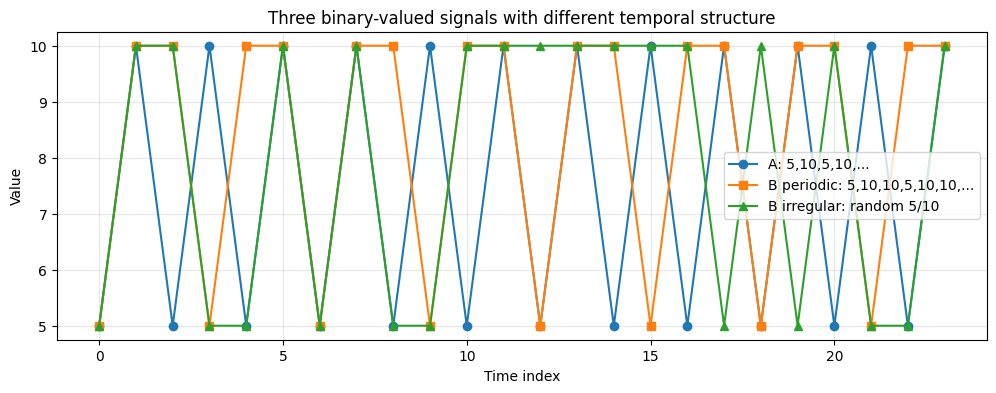

In [3]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(a[:24], marker="o", label="A: 5,10,5,10,...")
ax.plot(b_periodic[:24], marker="s", label="B periodic: 5,10,10,5,10,10,...")
ax.plot(b_irregular[:24], marker="^", label="B irregular: random 5/10")
ax.set_title("Three binary-valued signals with different temporal structure")
ax.set_xlabel("Time index")
ax.set_ylabel("Value")
ax.legend()
ax.grid(alpha=0.3)
plt.show()



## 2. Formal definition of Approximate Entropy

Let the time series be

\[
x_1, x_2, \dots, x_N.
\]

Choose two parameters:

- \(m\): the embedding dimension, or pattern length,
- \(r\): the tolerance used to decide whether two patterns are similar.

### Step 1: Build length-\(m\) vectors

For each valid starting index \(i\), define the block

\[
\mathbf{u}_i^{(m)} = (x_i, x_{i+1}, \dots, x_{i+m-1}),
\quad i = 1, 2, \dots, N-m+1.
\]

So we slide a window of length \(m\) across the series.

### Step 2: Compare blocks using a distance

ApEn commonly uses the **Chebyshev distance**:

\[
d\big(\mathbf{u}_i^{(m)}, \mathbf{u}_j^{(m)}\big)
=
\max_{0 \le k < m} |x_{i+k} - x_{j+k}|.
\]

Two blocks are considered similar if their distance is at most \(r\).

### Step 3: Count how many blocks are similar to each block

For each \(i\),

\[
C_i^{(m)}(r)
=
\frac{\#\left\{j : d\big(\mathbf{u}_i^{(m)}, \mathbf{u}_j^{(m)}\big) \le r\right\}}
{N-m+1}.
\]

A key detail of **Approximate Entropy** is that it includes **self-matches**.  
That means \(\mathbf{u}_i^{(m)}\) always matches itself.

### Step 4: Average the log-counts

Define

\[
\phi^{(m)}(r)
=
\frac{1}{N-m+1}
\sum_{i=1}^{N-m+1}
\log C_i^{(m)}(r).
\]

### Step 5: Define ApEn

\[
\operatorname{ApEn}(m, r, N)
=
\phi^{(m)}(r) - \phi^{(m+1)}(r).
\]

---

## Interpretation

If similar patterns of length \(m\) usually remain similar at length \(m+1\), then

- the \(C_i^{(m+1)}(r)\) values remain relatively large,
- the difference \(\phi^{(m)}(r) - \phi^{(m+1)}(r)\) stays small,
- and ApEn is **low**.

If extending the pattern by one point often destroys similarity, ApEn becomes **larger**.



## 3. Design choices for a serious implementation

A practical ApEn implementation needs to handle several details carefully:

1. **Input validation**  
   We should reject non-1D or too-short sequences.

2. **Tolerance choice**  
   In practice, a common rule is:
   `r = 0.2 * std(x)`  
   though this is a convention, not a law.

3. **Distance metric**  
   Classical ApEn uses the Chebyshev distance.

4. **Self-matches**  
   ApEn includes them. SampEn does not.

5. **Small-sample stability**  
   ApEn is more stable than exact matching entropy for short and noisy series, but still sensitive to parameter choices.

6. **Complexity**  
   A direct implementation compares many pairs of blocks and is typically `O(N^2)` in the number of windows.

Below we implement a reusable estimator with:
- explicit parameterization,
- vectorized block construction,
- pairwise Chebyshev distance computation,
- and a sliding-window mode for streaming analysis.


In [4]:

@dataclass(frozen=True)
class ApEnConfig:
    """Configuration for Approximate Entropy computation.

    Parameters
    ----------
    m:
        Embedding dimension. Typical values are 1 or 2.
    r:
        Absolute similarity tolerance. If None, it will be derived as
        `r_ratio * std(x)` inside the estimator.
    r_ratio:
        Multiplicative factor used to derive `r` from the sample standard
        deviation when `r` is not explicitly provided.
    """

    m: int = 2
    r: Optional[float] = None
    r_ratio: float = 0.2


class ApproximateEntropy:
    """Approximate Entropy estimator using Chebyshev distance.

    Notes
    -----
    This implementation follows the classical ApEn definition:
    - embedding vectors of length `m`,
    - Chebyshev distance,
    - self-matches included.

    The implementation is vectorized for clarity and numerical stability,
    though it still has quadratic cost in the number of embedding windows.
    """

    def __init__(self, config: ApEnConfig) -> None:
        if config.m < 1:
            raise ValueError("Embedding dimension m must be at least 1.")
        if config.r is not None and config.r < 0:
            raise ValueError("Tolerance r must be non-negative.")
        if config.r_ratio <= 0:
            raise ValueError("r_ratio must be strictly positive.")
        self.config = config

    @staticmethod
    def _validate_signal(x: Iterable[float]) -> np.ndarray:
        """Convert input to a valid one-dimensional floating-point array."""
        arr = np.asarray(list(x) if not isinstance(x, np.ndarray) else x, dtype=float)
        if arr.ndim != 1:
            raise ValueError("Input signal must be one-dimensional.")
        if arr.size < 3:
            raise ValueError("Input signal is too short for entropy analysis.")
        if not np.all(np.isfinite(arr)):
            raise ValueError("Input signal contains non-finite values.")
        return arr

    @staticmethod
    def _embed(signal: np.ndarray, m: int) -> np.ndarray:
        """Build overlapping embedding vectors of length `m`.

        Returns
        -------
        np.ndarray
            Array of shape (N - m + 1, m), where each row is an embedded block.
        """
        n = signal.size
        if m > n:
            raise ValueError("Embedding dimension cannot exceed signal length.")
        return np.lib.stride_tricks.sliding_window_view(signal, window_shape=m)

    @staticmethod
    def _chebyshev_distance_matrix(embedded: np.ndarray) -> np.ndarray:
        """Compute the full pairwise Chebyshev distance matrix.

        Parameters
        ----------
        embedded:
            Matrix of embedded windows with shape (n_windows, m).

        Returns
        -------
        np.ndarray
            Pairwise Chebyshev distances with shape (n_windows, n_windows).
        """
        # Broadcasted absolute differences over all window pairs.
        diff = np.abs(embedded[:, None, :] - embedded[None, :, :])
        # Chebyshev distance = maximum coordinate-wise deviation.
        return np.max(diff, axis=2)

    def _resolve_tolerance(self, x: np.ndarray) -> float:
        """Resolve the tolerance `r` from configuration and data."""
        if self.config.r is not None:
            return float(self.config.r)
        scale = float(np.std(x, ddof=0))
        # When the signal is constant, std is zero. In that case, a zero
        # tolerance is mathematically meaningful because all equal patterns match.
        return self.config.r_ratio * scale

    def _phi(self, x: np.ndarray, m: int, r: float) -> float:
        """Compute phi^m(r), the average log pattern-match frequency."""
        embedded = self._embed(x, m)
        distances = self._chebyshev_distance_matrix(embedded)

        # Classical ApEn includes self-matches, so each row always has at
        # least one match. This avoids log(0) in the ApEn formulation.
        match_counts = np.mean(distances <= r, axis=1)

        # Numerical guard: classical theory guarantees positive values because
        # of self-matches, but clipping protects against floating-point edge cases.
        match_counts = np.clip(match_counts, 1e-300, None)
        return float(np.mean(np.log(match_counts)))

    def compute(self, x: Iterable[float]) -> float:
        """Compute Approximate Entropy for a one-dimensional signal.

        Parameters
        ----------
        x:
            One-dimensional iterable representing the time series.

        Returns
        -------
        float
            Approximate Entropy value.

        Raises
        ------
        ValueError
            If the series is too short for the chosen embedding dimension.
        """
        signal = self._validate_signal(x)
        m = self.config.m
        if signal.size <= m + 1:
            raise ValueError(
                "Signal is too short for the chosen embedding dimension. "
                "Need at least m + 2 observations."
            )

        r = self._resolve_tolerance(signal)
        phi_m = self._phi(signal, m=m, r=r)
        phi_m1 = self._phi(signal, m=m + 1, r=r)
        return float(phi_m - phi_m1)

    def sliding_window(
        self,
        x: Iterable[float],
        window_size: int,
        step: int = 1,
    ) -> pd.DataFrame:
        """Compute ApEn on a sliding window over a signal.

        Parameters
        ----------
        x:
            One-dimensional signal.
        window_size:
            Number of observations per window.
        step:
            Step size between consecutive windows.

        Returns
        -------
        pd.DataFrame
            DataFrame with window start, window end, and ApEn value.
        """
        signal = self._validate_signal(x)

        if window_size <= self.config.m + 1:
            raise ValueError("window_size must be larger than m + 1.")
        if window_size > signal.size:
            raise ValueError("window_size cannot exceed signal length.")
        if step < 1:
            raise ValueError("step must be at least 1.")

        rows: list[dict[str, float]] = []
        for start in range(0, signal.size - window_size + 1, step):
            end = start + window_size
            value = self.compute(signal[start:end])
            rows.append({"start": start, "end": end, "apen": value})
        return pd.DataFrame(rows)



The class above is intentionally more robust than a quick notebook function.  
It uses a configuration object, validation, vectorized window construction, and a reusable sliding-window interface.

Now let us test it on our three toy signals.


In [5]:

apen = ApproximateEntropy(ApEnConfig(m=2, r_ratio=0.2))

results = pd.Series(
    {
        "A_periodic_2cycle": apen.compute(a),
        "B_periodic_3cycle": apen.compute(b_periodic),
        "B_irregular_binary": apen.compute(b_irregular),
    }
)
results.sort_values()


B_periodic_3cycle    -0.000007
A_periodic_2cycle     0.000144
B_irregular_binary    0.686855
dtype: float64


You should usually see:

- **very low ApEn** for the deterministic periodic sequences,
- and a **higher ApEn** for the irregular binary sequence.

This directly addresses the key point:

> ApEn reacts to temporal pattern regularity, not just to value frequency.

Notice also something conceptually important:

- the original `5, 10, 10, 5, 10, 10, ...` sequence is still low-entropy in the ApEn sense,
- because it is periodic and fully predictable once the cycle is known.



## 4. A small manual interpretation of pattern matching

To make the idea concrete, let us inspect length-2 windows from the alternating signal:

\[
(5,10), (10,5), (5,10), (10,5), \dots
\]

There are only two recurring patterns, and they repeat very consistently.  
When extended to length 3, they become:

\[
(5,10,5), (10,5,10), (5,10,5), (10,5,10), \dots
\]

Again, the extensions remain stable. This is exactly the setting where ApEn stays low.

For a random-looking binary signal, many short windows may look similar just by chance, but their one-step extensions do **not** remain stable nearly as often. That makes ApEn larger.



## 5. Sensitivity to noise

A useful sanity check is to start from a perfectly periodic signal and gradually add noise.

We expect:
- low ApEn for the clean periodic signal,
- higher ApEn as the noise amplitude grows.

This shows why ApEn is often used in physiology, industrial monitoring, and streaming analytics: it can reflect the transition from stable to irregular dynamics.


In [6]:

def noisy_periodic_signal(
    length: int,
    noise_std: float,
    seed: int = 0,
) -> np.ndarray:
    """Generate a sinusoidal signal plus Gaussian noise.

    Parameters
    ----------
    length:
        Number of observations.
    noise_std:
        Standard deviation of the Gaussian noise.
    seed:
        Random seed for reproducibility.
    """
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 8 * np.pi, length)
    base = np.sin(t)
    noise = rng.normal(loc=0.0, scale=noise_std, size=length)
    return base + noise


noise_levels = np.linspace(0.0, 1.0, 11)
noise_experiment = []

for sigma in noise_levels:
    signal = noisy_periodic_signal(length=300, noise_std=float(sigma), seed=123)
    estimator = ApproximateEntropy(ApEnConfig(m=2, r_ratio=0.2))
    noise_experiment.append({"noise_std": sigma, "apen": estimator.compute(signal)})

noise_df = pd.DataFrame(noise_experiment)
noise_df


,noise_std,apen
0,0.0,0.281410
1,0.1,0.697021
2,0.2,0.983788
3,0.3,1.129668
4,0.4,1.119162
5,0.5,1.125305
6,0.6,1.131125
7,0.7,1.128392
8,0.8,1.075201
9,0.9,1.067426


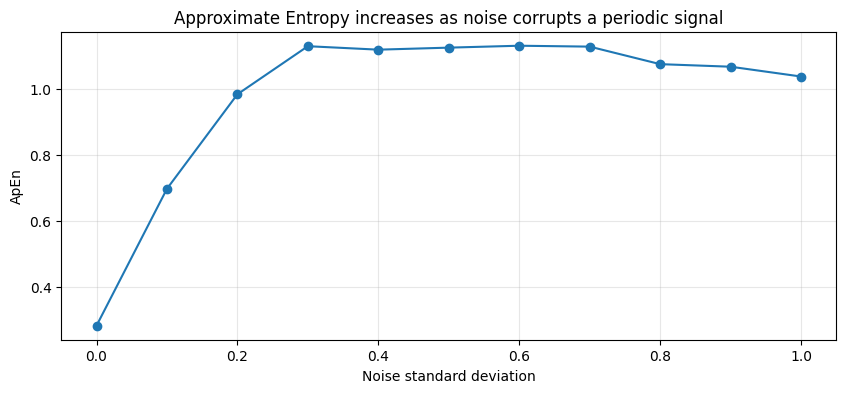

In [7]:

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(noise_df["noise_std"], noise_df["apen"], marker="o")
ax.set_title("Approximate Entropy increases as noise corrupts a periodic signal")
ax.set_xlabel("Noise standard deviation")
ax.set_ylabel("ApEn")
ax.grid(alpha=0.3)
plt.show()



The trend is the main point.  
As the signal loses regularity, ApEn rises.

This is one of the reasons ApEn is useful as a **monitoring feature**:
it can summarize how much temporal structure has degraded.



## 6. Sensitivity to parameters `m` and `r`

ApEn is not a single number attached to a series independently of modeling choices.  
It depends on:

- `m`: pattern length,
- `r`: similarity threshold.

### About `m`
- Small `m` is more stable.
- Large `m` needs more data, because the space of possible patterns grows quickly.

### About `r`
- Small `r` makes matching strict.
- Large `r` makes matching loose.

A common practical choice is:
- `m = 2`
- `r = 0.1` to `0.25` times the standard deviation.

Below we inspect how ApEn changes with `r`.


In [8]:

test_signal = noisy_periodic_signal(length=300, noise_std=0.35, seed=7)

ratios = np.linspace(0.05, 0.50, 10)
parameter_rows = []

for ratio in ratios:
    estimator = ApproximateEntropy(ApEnConfig(m=2, r_ratio=float(ratio)))
    parameter_rows.append({"r_ratio": ratio, "apen": estimator.compute(test_signal)})

parameter_df = pd.DataFrame(parameter_rows)
parameter_df


,r_ratio,apen
0,0.05,0.234385
1,0.10,0.673772
2,0.15,0.986834
3,0.20,1.124188
4,0.25,1.160717
5,0.30,1.101393
6,0.35,1.026305
7,0.40,0.951304
8,0.45,0.868847
9,0.50,0.776916


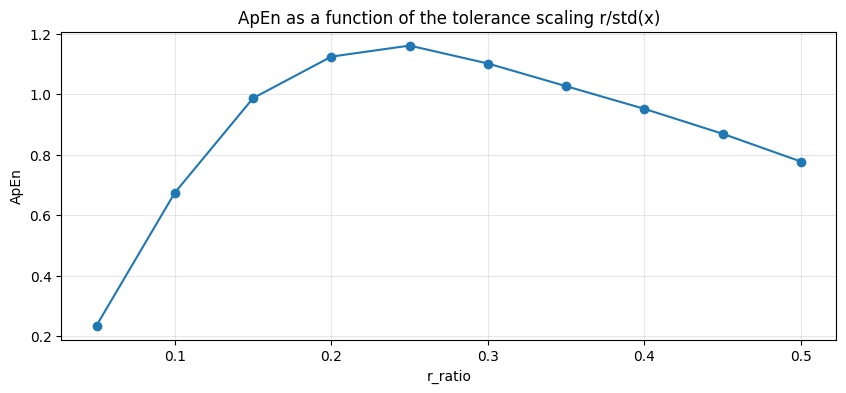

In [9]:

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(parameter_df["r_ratio"], parameter_df["apen"], marker="o")
ax.set_title("ApEn as a function of the tolerance scaling r/std(x)")
ax.set_xlabel("r_ratio")
ax.set_ylabel("ApEn")
ax.grid(alpha=0.3)
plt.show()



The value changes because the notion of “similar patterns” changes.

This is not a bug. It is a feature of the definition.  
ApEn measures regularity **relative to a chosen tolerance scale**.

In applied work, it is therefore important to report the parameter settings explicitly.



## 7. Comparison against a signal with the same mean and variance

We now build two signals with nearly the same mean and variance but different temporal organization:

1. a structured autoregressive signal,
2. a randomly permuted version of the same values.

The permutation preserves the marginal distribution almost exactly, but destroys the time ordering.


In [10]:

def simulate_ar1(
    length: int,
    phi: float,
    sigma: float,
    seed: int = 0,
) -> np.ndarray:
    """Simulate an AR(1) process.

    x_t = phi * x_{t-1} + epsilon_t
    """
    rng = np.random.default_rng(seed)
    x = np.zeros(length, dtype=float)
    eps = rng.normal(loc=0.0, scale=sigma, size=length)
    for t in range(1, length):
        x[t] = phi * x[t - 1] + eps[t]
    return x


structured = simulate_ar1(length=400, phi=0.9, sigma=0.4, seed=10)
shuffled = np.random.default_rng(10).permutation(structured)

comparison = pd.DataFrame(
    {
        "structured_ar1": describe_signal(structured),
        "shuffled_same_values": describe_signal(shuffled),
    }
)
comparison


,structured_ar1,shuffled_same_values
n,400.000000,400.000000
mean,-0.560205,-0.560205
variance,0.976507,0.976507
min,-3.897851,-3.897851
max,1.697026,1.697026


In [11]:

estimator = ApproximateEntropy(ApEnConfig(m=2, r_ratio=0.2))
pd.Series(
    {
        "structured_ar1_ApEn": estimator.compute(structured),
        "shuffled_same_values_ApEn": estimator.compute(shuffled),
    }
)


structured_ar1_ApEn          1.115272
shuffled_same_values_ApEn    1.254012
dtype: float64

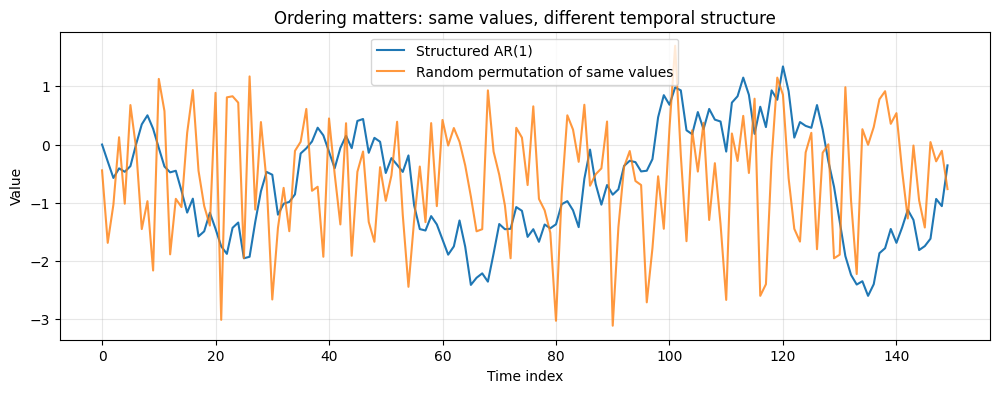

In [12]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(structured[:150], label="Structured AR(1)")
ax.plot(shuffled[:150], label="Random permutation of same values", alpha=0.8)
ax.set_title("Ordering matters: same values, different temporal structure")
ax.set_xlabel("Time index")
ax.set_ylabel("Value")
ax.legend()
ax.grid(alpha=0.3)
plt.show()



This example is often more convincing than the binary toy example.

The two signals use essentially the same values, so their means and variances are nearly the same.  
But the AR(1) process has local dependence, while the permuted version has that dependence removed.

ApEn should be lower for the structured AR(1) signal and higher for the shuffled signal.



## 8. Approximate Entropy for streaming data

In streaming systems, we rarely care about one global entropy value over a very long history.  
Instead, we want to know how regularity changes over time.

A standard approach is:

- choose a window size,
- compute ApEn on each window,
- track the result over time.

Below we simulate a **regime change**:

- first half: periodic with low noise,
- second half: much noisier and less regular.

ApEn should rise around the transition.


In [13]:

def regime_change_signal(length: int, seed: int = 0) -> np.ndarray:
    """Create a signal that changes from regular to irregular behavior."""
    if length < 20:
        raise ValueError("length must be at least 20 for a meaningful regime change.")

    rng = np.random.default_rng(seed)

    first_half = np.sin(np.linspace(0, 6 * np.pi, length // 2))
    first_half = first_half + rng.normal(0.0, 0.08, size=first_half.size)

    second_half = rng.normal(0.0, 1.0, size=length - length // 2)

    return np.concatenate([first_half, second_half])


stream_signal = regime_change_signal(length=600, seed=123)
stream_estimator = ApproximateEntropy(ApEnConfig(m=2, r_ratio=0.2))
stream_df = stream_estimator.sliding_window(stream_signal, window_size=80, step=5)
stream_df.head()


,start,end,apen
0,0,80,0.474645
1,5,85,0.418375
2,10,90,0.365598
3,15,95,0.380655
4,20,100,0.423584


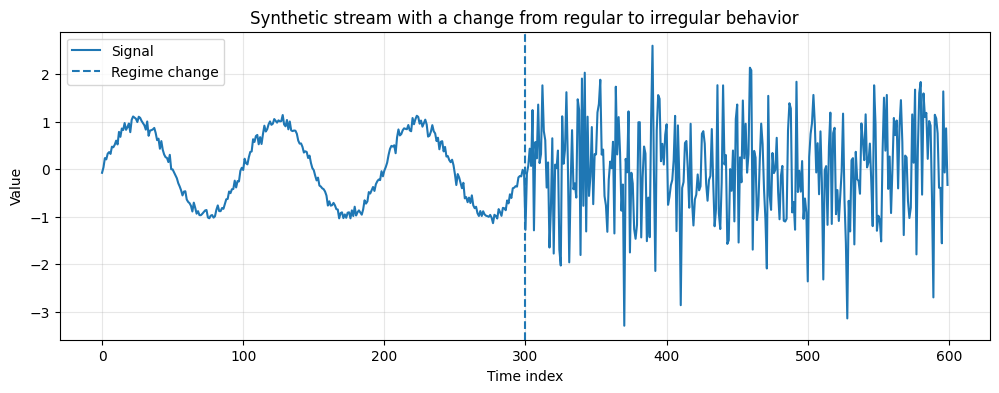

In [14]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stream_signal, label="Signal")
ax.axvline(len(stream_signal) // 2, linestyle="--", label="Regime change")
ax.set_title("Synthetic stream with a change from regular to irregular behavior")
ax.set_xlabel("Time index")
ax.set_ylabel("Value")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


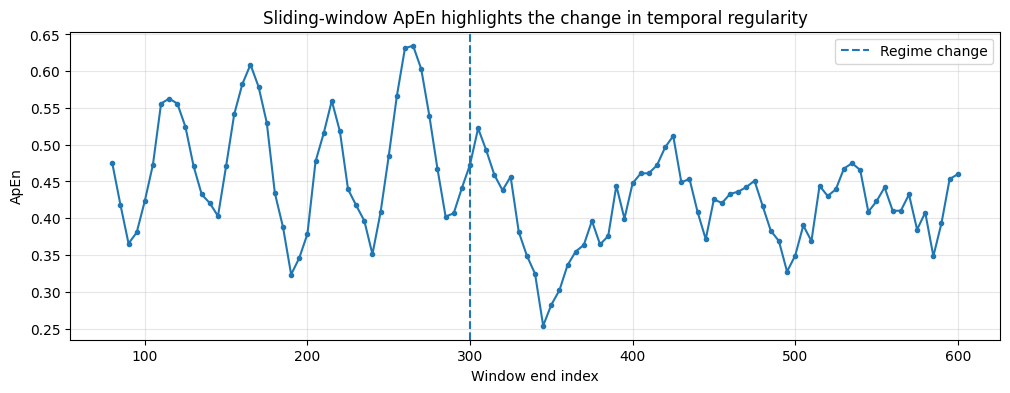

In [15]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stream_df["end"], stream_df["apen"], marker="o", markersize=3)
ax.axvline(len(stream_signal) // 2, linestyle="--", label="Regime change")
ax.set_title("Sliding-window ApEn highlights the change in temporal regularity")
ax.set_xlabel("Window end index")
ax.set_ylabel("ApEn")
ax.legend()
ax.grid(alpha=0.3)
plt.show()



This is the streaming-data view of ApEn:

- not as an abstract complexity measure,
- but as a dynamic feature that may help detect instability, degradation, or a shift in system behavior.

In practice, the sliding-window ApEn series can be fed into:
- anomaly detectors,
- online monitoring dashboards,
- adaptive thresholding pipelines,
- or downstream machine learning models.



## 9. Comparison with Sample Entropy (SampEn)

Approximate Entropy was an important step forward, but it is not the end of the story.

A common criticism is that ApEn:
- includes self-matches,
- and can be biased for short samples.

**Sample Entropy (SampEn)** is a related statistic that removes self-matches and changes the ratio slightly.

The interpretation is similar:
- lower values indicate more regularity,
- higher values indicate more irregularity.

Below we implement SampEn for comparison.


In [16]:

class SampleEntropy:
    """Sample Entropy estimator using Chebyshev distance.

    Notes
    -----
    SampEn differs from ApEn primarily by excluding self-matches and
    computing a log-ratio of average counts rather than averaging logs.
    """

    def __init__(self, m: int = 2, r: Optional[float] = None, r_ratio: float = 0.2) -> None:
        if m < 1:
            raise ValueError("Embedding dimension m must be at least 1.")
        if r is not None and r < 0:
            raise ValueError("Tolerance r must be non-negative.")
        if r_ratio <= 0:
            raise ValueError("r_ratio must be strictly positive.")
        self.m = m
        self.r = r
        self.r_ratio = r_ratio

    @staticmethod
    def _validate_signal(x: Iterable[float]) -> np.ndarray:
        arr = np.asarray(list(x) if not isinstance(x, np.ndarray) else x, dtype=float)
        if arr.ndim != 1:
            raise ValueError("Input signal must be one-dimensional.")
        if arr.size < 3:
            raise ValueError("Input signal is too short.")
        if not np.all(np.isfinite(arr)):
            raise ValueError("Input signal contains non-finite values.")
        return arr

    @staticmethod
    def _embed(signal: np.ndarray, m: int) -> np.ndarray:
        return np.lib.stride_tricks.sliding_window_view(signal, window_shape=m)

    @staticmethod
    def _distance_matrix(embedded: np.ndarray) -> np.ndarray:
        diff = np.abs(embedded[:, None, :] - embedded[None, :, :])
        return np.max(diff, axis=2)

    def _resolve_r(self, x: np.ndarray) -> float:
        if self.r is not None:
            return float(self.r)
        return self.r_ratio * float(np.std(x, ddof=0))

    def _average_match_probability(self, x: np.ndarray, m: int, r: float) -> float:
        embedded = self._embed(x, m)
        distances = self._distance_matrix(embedded)

        # Exclude self-matches for SampEn.
        n = distances.shape[0]
        mask = ~np.eye(n, dtype=bool)
        valid = distances[mask].reshape(n, n - 1)

        counts = np.sum(valid <= r, axis=1)
        denominator = max(n - 1, 1)
        proportions = counts / denominator

        return float(np.mean(proportions))

    def compute(self, x: Iterable[float]) -> float:
        signal = self._validate_signal(x)
        if signal.size <= self.m + 1:
            raise ValueError("Signal is too short for the chosen embedding dimension.")

        r = self._resolve_r(signal)

        a = self._average_match_probability(signal, self.m + 1, r)
        b = self._average_match_probability(signal, self.m, r)

        if a <= 0 or b <= 0:
            return float("inf")
        return float(-np.log(a / b))


In [17]:

sampen = SampleEntropy(m=2, r_ratio=0.2)

entropy_comparison = pd.DataFrame(
    {
        "ApEn": {
            "periodic_2cycle": ApproximateEntropy(ApEnConfig(m=2, r_ratio=0.2)).compute(a),
            "irregular_binary": ApproximateEntropy(ApEnConfig(m=2, r_ratio=0.2)).compute(b_irregular),
            "structured_ar1": ApproximateEntropy(ApEnConfig(m=2, r_ratio=0.2)).compute(structured),
        },
        "SampEn": {
            "periodic_2cycle": sampen.compute(a),
            "irregular_binary": sampen.compute(b_irregular),
            "structured_ar1": sampen.compute(structured),
        },
    }
)
entropy_comparison


,ApEn,SampEn
periodic_2cycle,0.000144,0.000605
irregular_binary,0.686855,0.754452
structured_ar1,1.115272,1.242786



The exact values differ, because the definitions differ.  
But the ranking is often similar:

- highly regular signals stay low,
- irregular signals move higher.

In practice, many modern workflows test both ApEn and SampEn.



## 10. Interpreting ApEn correctly

ApEn is very useful, but it is often oversold. A careful interpretation is:

- **ApEn is not a general-purpose uncertainty measure for all AI systems.**
- It is specifically a measure of **temporal irregularity / pattern unpredictability** in a sequence.

So the statement

> “ApEn measures uncertainty in AI-based systems”

is too broad.

A better phrasing is:

> “ApEn can be used as a feature that captures how irregular or unstable a time series has become.”

That makes sense in:
- sensor streams,
- physiological signals,
- market microstructure signals,
- machine telemetry,
- online monitoring,
- anomaly detection pipelines.

### In streaming machine learning

ApEn can be engineered as a feature over rolling windows and then used by:
- classifiers,
- drift detectors,
- anomaly scoring systems,
- or change-detection logic.

### In human-in-the-loop systems

ApEn does **not** replace human oversight.  
What it can do is help surface behavior that looks less regular than usual, which may deserve attention.



## 11. Limitations and practical warnings

Approximate Entropy has several limitations.

### 1. Parameter sensitivity
Different choices of `m` and `r` can change the result meaningfully.

### 2. Sample-size dependence
Short sequences can yield unstable estimates.

### 3. Scale dependence through `r`
If you define `r` relative to the signal's standard deviation, then rescaling the signal affects the threshold indirectly through that scale estimate.

### 4. Quadratic computational cost
The direct implementation is not ideal for very high-throughput streams.

### 5. Interpretation is contextual
High ApEn does not automatically mean “bad” or “anomalous.”  
It means the sequence is less regular under the chosen representation and tolerance.

For production use, ApEn is often:
- one feature among many,
- monitored relative to a baseline,
- and interpreted jointly with domain-specific context.



## 12. Summary

Approximate Entropy quantifies the extent to which **similar short patterns remain similar one step later**.

That makes it useful when:
- order matters,
- ordinary summary statistics are not enough,
- and we care about how regularity changes over time.

### Key takeaways

- Mean and variance ignore time ordering.
- ApEn measures **pattern regularity**, not just value dispersion.
- Periodic signals tend to have low ApEn.
- Random or noisy signals tend to have higher ApEn.
- Sliding-window ApEn is useful for **streaming data analysis**.
- Parameter choices must be reported carefully.
- SampEn is a closely related alternative worth knowing.

---

## 13. Suggested extensions

A good next step would be to extend this notebook with one or more of the following:

1. **Multiscale entropy**  
   Compute entropy after coarse-graining at several scales.

2. **Permutation entropy**  
   Use ordinal patterns instead of amplitude-based matching.

3. **Online approximation**  
   Build a faster approximate rolling implementation for high-throughput streams.

4. **Real dataset experiment**  
   Apply ApEn to ECG, sensor telemetry, market data, or machine logs.

5. **Regime detection pipeline**  
   Use rolling ApEn as an input feature for a classifier or drift detector.

This notebook gives the mathematical and computational foundation for those directions.
